In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported successfully!
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [2]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
movies = pd.read_csv('../data/ml-25m/movies.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test:  {len(test):,} ratings")
print(f"Movies: {len(movies):,}")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")

Train: 17,436,354 ratings
Test:  7,563,741 ratings
Movies: 62,423
Rating range: 0.00 - 1.00


In [3]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Cold start users in test: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Cold start users in test: 6,836,326


In [4]:
class GMF(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32, dropout=0.3):
        super(GMF, self).__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        self.dropout = nn.Dropout(p=dropout)
        self.bn = nn.BatchNorm1d(embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, 1)

    def forward(self, user_indices, movie_indices):
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices)
        interaction = user_vec * movie_vec
        interaction = self.dropout(self.bn(interaction))
        output = self.output_layer(interaction)
        return output.squeeze()

gmf_model = GMF(n_users, n_movies, embedding_dim=32, dropout=0.3).to(device)
gmf_model.load_state_dict(
    torch.load('../models/gmf_regularized_best.pth', map_location=device))
gmf_model.eval()

all_genres = set()
for genres in movies['genres'].str.split('|'):
    all_genres.update(genres)
all_genres.discard('(no genres listed)')
all_genres = sorted(list(all_genres))

def create_genre_vector(genres_str, all_genres):
    genres = genres_str.split('|')
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genres:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

movies['genre_vector'] = movies['genres'].apply(
    lambda x: create_genre_vector(x, all_genres))
movie_id_to_genre = dict(zip(movies['movieId'], movies['genre_vector']))

print(f"GMF model loaded")
print(f"Genres loaded: {len(all_genres)}")
print(f"Movie genre vectors: {len(movie_id_to_genre):,}")

GMF model loaded
Genres loaded: 19
Movie genre vectors: 62,423


In [5]:
def get_genre_vector(genre_list, all_genres):
    """Convert list of genre strings to preference vector"""
    vector = np.zeros(len(all_genres), dtype=np.float32)
    for genre in genre_list:
        if genre in all_genres:
            idx = all_genres.index(genre)
            vector[idx] = 1.0
    return vector

print("get_genre_vector()")

get_genre_vector()


In [6]:
def cold_start_recommendations_v2(
        preferred_genres,
        all_genres,
        movie_id_to_genre,
        movies,
        movie_stats,
        max_num_ratings,
        top_k=10,
        min_ratings=50,
        popularity_weight=0.2):
    
    user_vector = get_genre_vector(preferred_genres, all_genres)
    
    recommendations = []
    for movie_id, genre_vector in movie_id_to_genre.items():
        similarity = np.dot(user_vector, genre_vector)
        if similarity > 0 and movie_id in movie_stats.index:
            stats = movie_stats.loc[movie_id]
            if stats['num_ratings'] >= min_ratings:
                popularity_score = (np.log1p(stats['num_ratings']) /
                                   np.log1p(max_num_ratings))
                combined_score = (similarity *
                                 stats['avg_rating'] *
                                 (1 + popularity_weight * popularity_score))
                recommendations.append({
                    'movieId': movie_id,
                    'similarity': similarity,
                    'avg_rating': round(float(stats['avg_rating']), 2),
                    'num_ratings': int(stats['num_ratings']),
                    'popularity_score': round(float(popularity_score), 3),
                    'combined_score': round(combined_score, 3)
                })
    
    recommendations = sorted(recommendations,
                             key=lambda x: x['combined_score'],
                             reverse=True)[:top_k]
    
    movie_titles = dict(zip(movies['movieId'], movies['title']))
    movie_genres_dict = dict(zip(movies['movieId'], movies['genres']))
    
    results = []
    for i, rec in enumerate(recommendations):
        results.append({
            'rank': i + 1,
            'movieId': rec['movieId'],
            'title': movie_titles.get(rec['movieId'], 'Unknown'),
            'genres': movie_genres_dict.get(rec['movieId'], 'Unknown'),
            'avg_rating': rec['avg_rating'],
            'num_ratings': rec['num_ratings'],
            'popularity_score': rec['popularity_score'],
            'combined_score': rec['combined_score']
        })
    
    return pd.DataFrame(results)

print("cold_start_recommendations_v2()")

cold_start_recommendations_v2()


In [7]:
movie_stats_precomputed = train.groupby('movieId')['rating'].agg(['mean', 'count'])
movie_stats_precomputed.columns = ['avg_rating', 'num_ratings']
movie_stats_precomputed['avg_rating'] = (movie_stats_precomputed['avg_rating'] *
                                          (max_rating - min_rating)) + min_rating
max_num_ratings = movie_stats_precomputed['num_ratings'].max()

# Sample cold start users
np.random.seed(42)
test_users = set(test['userId'].unique())
train_users = set(train['userId'].unique())
cold_start_users = test_users - train_users
sample_users = np.random.choice(
    list(cold_start_users),
    size=min(1000, len(cold_start_users)),
    replace=False)

print(f"Movie stats precomputed: {len(movie_stats_precomputed):,} movies")
print(f"Max ratings any movie:   {max_num_ratings:,}")
print(f"Sample users:            {len(sample_users):,} cold start users")

Movie stats precomputed: 22,316 movies
Max ratings any movie:   59,021
Sample users:            1,000 cold start users


In [8]:
def get_user_genres(user_id, test, movies):
    """Infer genre preferences from what user actually rated in test"""
    user_test_movies = test[test['userId'] == user_id]['movieId'].values
    
    genre_counts = {}
    for movie_id in user_test_movies:
        movie_row = movies[movies['movieId'] == movie_id]
        if len(movie_row) == 0:
            continue
        genres = movie_row.iloc[0]['genres'].split('|')
        for genre in genres:
            if genre != '(no genres listed)':
                genre_counts[genre] = genre_counts.get(genre, 0) + 1
    
    if not genre_counts:
        return []
    
    sorted_genres = sorted(genre_counts.items(),
                          key=lambda x: x[1], reverse=True)
    return [g[0] for g in sorted_genres[:2]]

print("get_user_genres()")

get_user_genres()


In [9]:
def precision_at_k(recommended_movies, relevant_movies, k):
    """
    Of our top K recommendations how many were relevant?
    precision@k = hits in top k / k
    """
    top_k = set(recommended_movies[:k])
    relevant = set(relevant_movies)
    hits = len(top_k & relevant)
    return hits / k if k > 0 else 0.0

def recall_at_k(recommended_movies, relevant_movies, k):
    """
    Of all relevant movies how many did we find in top K?
    recall@k = hits in top k / total relevant
    """
    top_k = set(recommended_movies[:k])
    relevant = set(relevant_movies)
    hits = len(top_k & relevant)
    return hits / len(relevant) if len(relevant) > 0 else 0.0

def dcg_at_k(recommended_movies, relevant_movies, k):
    """
    Discounted Cumulative Gain — rewards hits at higher ranks
    DCG = sum of (1 / log2(rank + 1)) for each hit
    """
    relevant = set(relevant_movies)
    dcg = 0.0
    for rank, movie_id in enumerate(recommended_movies[:k], start=1):
        if movie_id in relevant:
            dcg += 1.0 / np.log2(rank + 1)
    return dcg

def ndcg_at_k(recommended_movies, relevant_movies, k):
    """
    Normalized DCG — compares against perfect ranking
    NDCG = DCG / ideal DCG
    Ranges from 0.0 (worst) to 1.0 (perfect)
    """
    # Actual DCG
    actual_dcg = dcg_at_k(recommended_movies, relevant_movies, k)
    
    # Ideal DCG — all hits at top ranks
    n_relevant = min(len(relevant_movies), k)
    ideal_recommended = list(relevant_movies)[:n_relevant]
    ideal_dcg = dcg_at_k(ideal_recommended, relevant_movies, k)
    
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

print("="*50)

recommended = ['Matrix', 'Titanic', 'Inception', 'Avengers', 'Toy Story']
relevant     = ['Matrix', 'Inception', 'Blade Runner', 'Goodfellas', 'Pulp Fiction']

p5 = precision_at_k(recommended, relevant, k=5)
r5 = recall_at_k(recommended, relevant, k=5)
n5 = ndcg_at_k(recommended, relevant, k=5)

print(f"Recommendations: {recommended}")
print(f"Relevant movies: {relevant}")
print(f"\nPrecision@5: {p5:.3f} (2 hits / 5 recommendations)")
print(f"Recall@5:    {r5:.3f} (2 hits / 5 relevant movies)")
print(f"NDCG@5:      {n5:.3f} (hits at ranks 1 and 3)")

print(f"  Hit at rank 1: 1/log2(2) = {1/np.log2(2):.3f}")
print(f"  Hit at rank 3: 1/log2(4) = {1/np.log2(4):.3f}")
print(f"  Hit at rank 5: 1/log2(6) = {1/np.log2(6):.3f}")
print(f"  Hit at rank 10: 1/log2(11) = {1/np.log2(11):.3f}")

print(f"\nAll three metric functions")
print(f"  precision_at_k()")
print(f"  recall_at_k()")
print(f"  ndcg_at_k()")

Recommendations: ['Matrix', 'Titanic', 'Inception', 'Avengers', 'Toy Story']
Relevant movies: ['Matrix', 'Inception', 'Blade Runner', 'Goodfellas', 'Pulp Fiction']

Precision@5: 0.400 (2 hits / 5 recommendations)
Recall@5:    0.400 (2 hits / 5 relevant movies)
NDCG@5:      0.509 (hits at ranks 1 and 3)
  Hit at rank 1: 1/log2(2) = 1.000
  Hit at rank 3: 1/log2(4) = 0.500
  Hit at rank 5: 1/log2(6) = 0.387
  Hit at rank 10: 1/log2(11) = 0.289

All three metric functions
  precision_at_k()
  recall_at_k()
  ndcg_at_k()


In [10]:
k_values = [5, 10, 20]

# Storage for results
results_store = {k: {
    'precision': [],
    'recall': [],
    'ndcg': []
} for k in k_values}

total = 0
skipped = 0

print(f"Evaluating ranking metrics across {len(sample_users):,} users...")
print(f"K values: {k_values}")
print(f"Metrics: Precision@K, Recall@K, NDCG@K")
print("=" * 55)

for i, user_id in enumerate(sample_users):
    if i % 100 == 0:
        print(f"Progress: {i}/{len(sample_users)} users evaluated...")

    # Get user's actual rated movies in test
    user_actual = list(
        test[test['userId'] == user_id]['movieId'].values)

    if len(user_actual) == 0:
        skipped += 1
        continue

    # Infer genre preferences
    preferred_genres = get_user_genres(user_id, test, movies)

    if len(preferred_genres) == 0:
        skipped += 1
        continue

    # Get top 20 recommendations (max K) in single pass
    recs = cold_start_recommendations_v2(
        preferred_genres=preferred_genres,
        all_genres=all_genres,
        movie_id_to_genre=movie_id_to_genre,
        movies=movies,
        movie_stats=movie_stats_precomputed,
        max_num_ratings=max_num_ratings,
        top_k=20,
        min_ratings=50,
        popularity_weight=0.2
    )

    if 'movieId' not in recs.columns or len(recs) == 0:
        skipped += 1
        continue

    recommended_movies = recs['movieId'].values.tolist()

    # Calculate metrics at each K
    for k in k_values:
        p = precision_at_k(recommended_movies, user_actual, k)
        r = recall_at_k(recommended_movies, user_actual, k)
        n = ndcg_at_k(recommended_movies, user_actual, k)

        results_store[k]['precision'].append(p)
        results_store[k]['recall'].append(r)
        results_store[k]['ndcg'].append(n)

    total += 1

print("=" * 55)
print(f"\nEvaluation complete")
print(f"  Users evaluated: {total:,}")
print(f"  Users skipped:   {skipped:,}")

# Calculate averages
print(f"\nResults:")
print(f"{'Metric':<15} {'K=5':>10} {'K=10':>10} {'K=20':>10}")
print("-" * 45)

for metric in ['precision', 'recall', 'ndcg']:
    row = f"{metric.capitalize()+'@K':<15}"
    for k in k_values:
        avg = np.mean(results_store[k][metric])
        row += f"{avg:>10.4f}"
    print(row)

Evaluating ranking metrics across 1,000 users...
K values: [5, 10, 20]
Metrics: Precision@K, Recall@K, NDCG@K
Progress: 0/1000 users evaluated...
Progress: 100/1000 users evaluated...
Progress: 200/1000 users evaluated...
Progress: 300/1000 users evaluated...
Progress: 400/1000 users evaluated...
Progress: 500/1000 users evaluated...
Progress: 600/1000 users evaluated...
Progress: 700/1000 users evaluated...
Progress: 800/1000 users evaluated...
Progress: 900/1000 users evaluated...

Evaluation complete
  Users evaluated: 983
  Users skipped:   17

Results:
Metric                 K=5       K=10       K=20
---------------------------------------------
Precision@K        0.4208    0.3532    0.2622
Recall@K           0.0311    0.0506    0.0711
Ndcg@K             0.4578    0.3987    0.3184


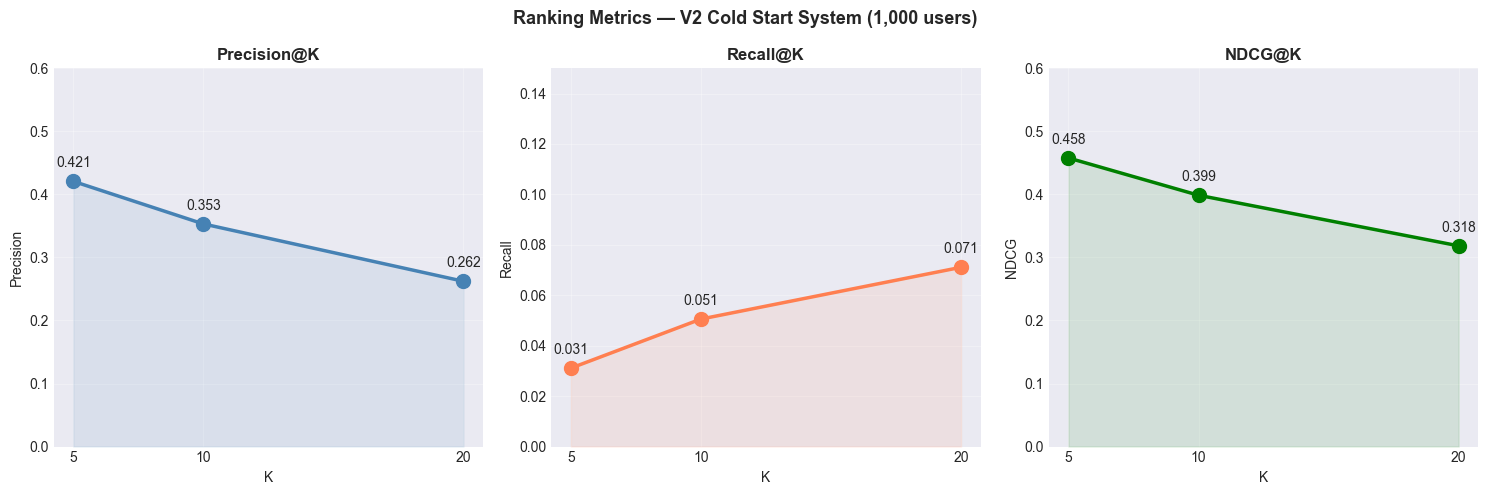


Summary:
  Precision@5:  0.4208 ← 42% of top 5 are relevant
  Recall@5:     0.0311 ← finds 3.1% of all relevant movies
  NDCG@5:       0.4578 ← strong ranking quality

  Precision@10: 0.3532
  Recall@10:    0.0506
  NDCG@10:      0.3987

  Precision@20: 0.2622
  Recall@20:    0.0711
  NDCG@20:      0.3184


In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

k_list = k_values
precision_vals = [np.mean(results_store[k]['precision']) for k in k_list]
recall_vals = [np.mean(results_store[k]['recall']) for k in k_list]
ndcg_vals = [np.mean(results_store[k]['ndcg']) for k in k_list]

# Plot 1 — Precision@K
ax1.plot(k_list, precision_vals, marker='o', linewidth=2.5,
         color='steelblue', markersize=10)
ax1.fill_between(k_list, precision_vals, alpha=0.1, color='steelblue')
for k, v in zip(k_list, precision_vals):
    ax1.annotate(f'{v:.3f}',
                xy=(k, v), xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=10)
ax1.set_title('Precision@K', fontweight='bold')
ax1.set_xlabel('K')
ax1.set_ylabel('Precision')
ax1.set_xticks(k_list)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 0.6)

# Plot 2 — Recall@K
ax2.plot(k_list, recall_vals, marker='o', linewidth=2.5,
         color='coral', markersize=10)
ax2.fill_between(k_list, recall_vals, alpha=0.1, color='coral')
for k, v in zip(k_list, recall_vals):
    ax2.annotate(f'{v:.3f}',
                xy=(k, v), xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=10)
ax2.set_title('Recall@K', fontweight='bold')
ax2.set_xlabel('K')
ax2.set_ylabel('Recall')
ax2.set_xticks(k_list)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 0.15)

# Plot 3 — NDCG@K
ax3.plot(k_list, ndcg_vals, marker='o', linewidth=2.5,
         color='green', markersize=10)
ax3.fill_between(k_list, ndcg_vals, alpha=0.1, color='green')
for k, v in zip(k_list, ndcg_vals):
    ax3.annotate(f'{v:.3f}',
                xy=(k, v), xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=10)
ax3.set_title('NDCG@K', fontweight='bold')
ax3.set_xlabel('K')
ax3.set_ylabel('NDCG')
ax3.set_xticks(k_list)
ax3.grid(alpha=0.3)
ax3.set_ylim(0, 0.6)

plt.suptitle('Ranking Metrics — V2 Cold Start System (1,000 users)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../models/ranking_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  Precision@5:  {precision_vals[0]:.4f}")
print(f"  Recall@5:     {recall_vals[0]:.4f}")
print(f"  NDCG@5:       {ndcg_vals[0]:.4f}")
print(f"\n  Precision@10: {precision_vals[1]:.4f}")
print(f"  Recall@10:    {recall_vals[1]:.4f}")
print(f"  NDCG@10:      {ndcg_vals[1]:.4f}")
print(f"\n  Precision@20: {precision_vals[2]:.4f}")
print(f"  Recall@20:    {recall_vals[2]:.4f}")
print(f"  NDCG@20:      {ndcg_vals[2]:.4f}")

## Notebook 12 Summary: Ranking Metrics

### Objective
Move beyond binary hit rate to ranking-aware metrics that
capture recommendation quality, coverage, and ordering.

### Three Metrics Implemented

**Precision@K**
```
Precision@K = hits in top K / K
High precision → every recommendation counts
Drops as K increases (more noise added)
```

**Recall@K**
```
Recall@K = hits in top K / total relevant movies
High recall → we find everything user likes
Rises as K increases (wider net catches more)
```

**NDCG@K**
```
DCG  = sum of 1/log2(rank+1) for each hit
NDCG = DCG / ideal DCG
Range: 0.0 (worst) to 1.0 (perfect)

Discount values:
  Rank 1:  1.000 ← full value
  Rank 3:  0.500 ← half value
  Rank 5:  0.387
  Rank 10: 0.289 ← less than a third
```

### Results — V2 Cold Start System (1,000 users)
| Metric | K=5 | K=10 | K=20 |
|--------|-----|------|------|
| Precision@K | 0.4208 | 0.3532 | 0.2622 |
| Recall@K | 0.0311 | 0.0506 | 0.0711 |
| NDCG@K | 0.4578 | 0.3987 | 0.3184 |

### Interpretation

**Precision@5 = 0.4208:**
```
42% of our top 5 recommendations are relevant
Nearly half our recommendations hit the mark
Strong result for a cold start system with no rating history
```

**Recall@5 = 0.0311:**
```
We find 3.1% of all relevant movies
Low but expected — cold start users rated ~180 movies
Our top 5 can only find 5 of those 180 (2.8%)
Not a weakness — a mathematical limitation of K=5
```

**NDCG@5 = 0.4578:**
```
Strong ranking quality — best items genuinely ranked highest
Not just accidentally hitting — our scoring puts
relevant movies near the top of the list
```

### The Fundamental Tradeoff
```
Precision and NDCG: favor smaller K (quality over quantity)
Recall:             favors larger K (quantity over quality)

K=10 sweet spot:
  Precision@10: 0.3532 → still 35% accuracy
  Recall@10:    0.0506 → finds 5% of relevant movies
  NDCG@10:      0.3987 → strong ranking quality
```

This precision/recall tradeoff exists in every production
recommender system — Netflix, Spotify, Amazon all face it.

### Complete Cold Start Performance Summary
```
Hit Rate (V2, K=10):    93.31% ← binary overlap metric
Precision@10:           0.3532 ← accuracy of recommendations
Recall@10:              0.0506 ← coverage of relevant movies
NDCG@10:                0.3987 ← ranking quality
```

### Key Findings
1. 42% precision at K=5 is strong for cold start
   → Nearly half of top 5 recommendations are relevant
2. Low recall is expected not alarming
   → Mathematical limitation of recommending 5-10 from 180+
3. NDCG 0.46 confirms our scoring puts best items first
   → genre_match × avg_rating × popularity is well ordered
4. All three metrics confirm K=10 as production sweet spot
   → Consistent with Top K sensitivity analysis from Day 17